# ANÁLISIS EXPLORATORIO Y TRANSFORMACIÓN DE DATOS

### Librerias y Carga de datos


In [4]:
!pip install pandas numpy matplotlib seaborn plotly
!pip install scikit-learn scipy
!pip install missingno
!pip install sweetviz
!pip install pandas-profiling
!pip install imbalanced-learn
!pip install openpyxl
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.1 MB 6.7 MB/s eta 0:00:03
   ---- ----------------------------------- 1.8/15.1 MB 4.8 MB/s eta 0:00:03
   --------- ------------------------------ 3.7/15.1 MB 6.4 MB/s eta 0:00:02
   -------------- ------------------------- 5.5/15.1 MB 6.8 MB/s eta 0:00:02
   ------------------- -------------------- 7.3/15.1 MB 7.2 MB/s eta 0:00:02
   ----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.5.2 requires joblib>=1.2.0, but you have joblib 1.1.1 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable

  Attempting uninstall: joblib

    Found existing installation: joblib 1.1.1

    Uninstalling joblib-1.1.1:

      Successfully uninstalled joblib-1.1.1

   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------------------------- 0/3 [joblib]
   ---------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------

In [5]:
# Importación de librerías para EDA y preprocesamiento de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import unicodedata
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import stats

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configuración de warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_excel('../../data.xlsx')

print(f"Datos originales:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

# Filtrar solo casos críticos
df = df[df['Hallazgo Crítico'] == 1]

print(f"\n{'='*50}")
print(f"Después de filtrar por casos críticos:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

print(f"\nValores nulos después del filtrado:")
print(df.isnull().sum())


Datos originales:
  - Filas: 3984
  - Columnas: 11

Después de filtrar por casos críticos:
  - Filas: 897
  - Columnas: 11

Valores nulos después del filtrado:
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     3
Hallazgos                          1
Opinión                            2
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


In [7]:
# Revisar registros con valores nulos en columnas clave antes de limpiar
print("\nRegistros con Datos Clínicos nulo:")
display(df[df['Datos Clínicos'].isnull()])
print("\nRegistro con Hallazgos nulo:")
display(df[df['Hallazgos'].isnull()])
print("\nRegistros con Opinión nulo:")
display(df[df['Opinión'].isnull()])


Registros con Datos Clínicos nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
3704,2025-01-07 20:06:25,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,"961.5 DLP (mGy - cm)\nEn equipo multidetector,...",NaN,Cambios postquirúrgicos por orificios de trépa...,Hematoma subdural fronto-temporoparietal izqui...,0,0,1,0.0
3828,2025-06-09 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,1279.55 DLP (mGy - cm)\nMedio de contraste: NO...,NaN,En este control se observa nueva pérdida difus...,Pérdida difusa de la diferenciación entre sust...,0,0,1,0.0
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0



Registro con Hallazgos nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0



Registros con Opinión nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
3805,2025-06-15 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,2674.8 DLP (mGy - cm)\nMedio de contraste: NO ...,POLITRAUMA POR ACCIDENTE DE TRANSITO -.,Hematoma epidural frontal izquierdo con espeso...,NaN,0,0,1,0.0
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0


In [8]:
# Limpieza recomendada para entrenamiento de modelos
df['Datos Clínicos'] = df['Datos Clínicos'].fillna('NR')  # Solo si Hallazgos y Opinión están presentes
df = df.dropna(subset=['Hallazgos', 'Opinión'])  # Elimina registros sin texto o sin etiqueta
print('Registros restantes tras limpieza:')
print(df.shape)
print('Valores nulos por columna:')
print(df.isnull().sum())

Registros restantes tras limpieza:
(895, 11)
Valores nulos por columna:
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


In [9]:
df['Datos Clínicos'] = df['Datos Clínicos'].fillna('NR')
df['Técnica'] = df['Técnica'].fillna('NR')
df['Estudio Normal'] = df['Estudio Normal'].fillna(0)
# Eliminamos las filas con nulos en 'Hallazgos' o 'Opinión'
df = df.dropna(subset=['Hallazgos', 'Opinión'])
# Verificar valores nulos después de la limpieza
print(df.isnull().sum())

Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


In [10]:
# Columnas de texto no estructurado a normalizar
text_columns = ['Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión']

for col in text_columns:
    # Convertir a string (por si hay valores numéricos o NaN)
    df[col] = df[col].astype(str)
    
    # Convertir a minúsculas
    df[col] = df[col].str.lower()
    
    # Eliminar espacios extra al inicio y final
    df[col] = df[col].str.strip()
    
    # Reemplazar múltiples espacios por un solo espacio
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
    
    # Normalizar puntuación: agregar espacio después de puntos, comas, etc.
    df[col] = df[col].str.replace(r'([.,:;!?])', r'\1 ', regex=True)
    
    # Eliminar espacios extra nuevamente
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

print("Normalización de texto no estructurado completada")

Normalización de texto no estructurado completada


In [11]:
for col in ['Modalidad', 'Estudio', 'Técnica', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Modalidad value counts:
Modalidad
CT    895
Name: count, dtype: int64

Estudio value counts:
Estudio
TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE                                        382
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE                                        278
 TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE                                       216
TOMOGRAFIA COMPUTADA DE CRANEO                                                 4
TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE YCON CONTRASTE                           4
TOMOGRAFÍA COMPUTADA DE CRÁNEO CON CONTRASTE                                   3
TOMOGRAFIA COMPUTADA DE CRANEO Y COLUMNA CERVICAL SIMPLE                       1
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE CON ANGIOTAC DE ARTERIAS CEREBRALES      1
TOMOGRAFIA COMPUTADA DE CRANEO Simple                                          1
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE Y CON CONTRASTE                          1
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE.                                         1
COMPUTA

In [12]:
def remove_accents(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_estudio(value):
    v = str(value).lower().strip()
    v = remove_accents(v)
    v = re.sub(r'\s+', ' ', v)
    v = v.replace('.', '')  # Elimina puntos finales
    # Angiotac (debe ir antes de "simple")
    if 'angiotac' in v:
        return 'tomografia computada de craneo simple con angiotac de arterias cerebrales'
    # Agrupar variantes de "simple"
    if re.search(r'tomografia computada de craneo simple', v) or \
        re.search(r'tomografia computada de craneo simpl', v) or \
        re.search(r'tomografia computada de craneo$', v) or \
        re.search(r'tomografia computada de crane$', v) or \
        re.search(r'tomografia computada de craneo simplev', v) or\
        re.search(r'tomografia axial computarizada de craneo simple dentro de limites normales', v) or\
        re.search(r'trauma craneoencefalico, cefalea y emesis', v) or\
        re.search(r'computada de craneo simple', v):
            return 'tomografia computada de craneo simple'
    # Agrupar variantes de "con contraste"
    if 'contraste' in v:
        return 'tomografia computada de craneo con contraste'
    # Agrupar columna cervical
    if 'columna cervical' in v:
        return 'tomografia computada de craneo y columna cervical simple'
    # TAC de recien nacidos
    if 'recien nacidos' in v:
        return 'tac de craneo simple recien nacidos'
    # Trauma, cefalea, emesis (caso único)
    if 'trauma' in v or 'cefalea' in v or 'emesis' in v:
        return v  # Mantener tal cual, es un caso único
    # Si nada coincide, devolver el valor normalizado
    return v

df['Estudio'] = df['Estudio'].apply(normalize_estudio)
print(df['Estudio'].value_counts())
print("Normalización de columna 'Estudio' completada")

Estudio
tomografia computada de craneo simple                                        890
tomografia computada de craneo con contraste                                   3
tomografia computada de craneo y columna cervical simple                       1
tomografia computada de craneo simple con angiotac de arterias cerebrales      1
Name: count, dtype: int64
Normalización de columna 'Estudio' completada


In [13]:
# Verificar distribución de valores binarios
print("Distribución de Hallazgo Crítico:")
print(df['Hallazgo Crítico'].value_counts())

print("\nDistribución de Estudio Normal:")
print(df['Estudio Normal'].value_counts())

print("\nDistribución de Reporte estructurado:")
print(df['Reporte estructurado'].value_counts())

print("\nDistribución de Estudio Complementario Sugerido:")
print(df['Estudio Complementario Sugerido'].value_counts())

Distribución de Hallazgo Crítico:
Hallazgo Crítico
1    895
Name: count, dtype: int64

Distribución de Estudio Normal:
Estudio Normal
0.0    895
Name: count, dtype: int64

Distribución de Reporte estructurado:
Reporte estructurado
0    624
1    271
Name: count, dtype: int64

Distribución de Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    848
1     47
Name: count, dtype: int64



Reporte estructurado:
Reporte estructurado
0    624
1    271
Name: count, dtype: int64
Proporción de 1: 0.3027932960893855

Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    848
1     47
Name: count, dtype: int64
Proporción de 1: 0.05251396648044693


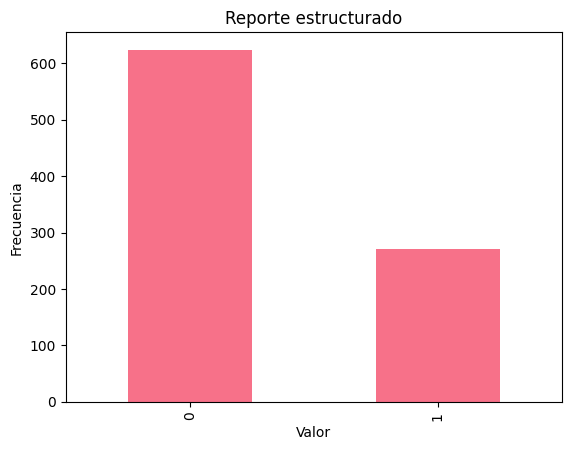

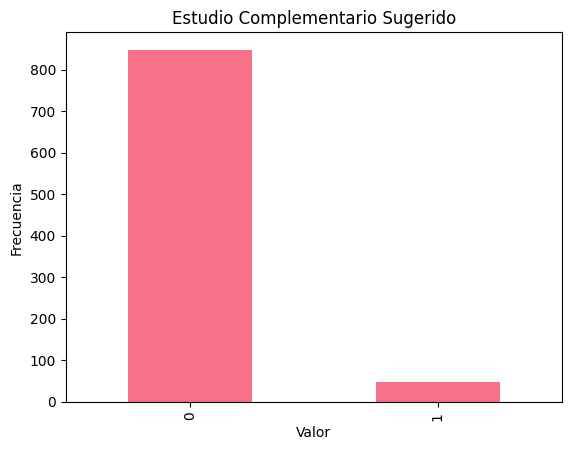

In [14]:
binary_cols = ['Reporte estructurado', 'Estudio Complementario Sugerido']

for col in binary_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("Proporción de 1:", df[col].mean())

for col in binary_cols:
    df[col].value_counts().plot(kind='bar', title=col)
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.show()

In [15]:
# Muestra aleatoria de hallazgos y opiniones
print(df['Hallazgos'].sample(20, random_state=1))
print(df['Opinión'].sample(20, random_state=1))

all_text = ' '.join(df['Hallazgos'].dropna().astype(str).tolist()).lower()
words = re.findall(r'\b\w+\b', all_text)
counter = Counter(words)
print(counter.most_common(50))  # 50 palabras más frecuentes

vectorizer = CountVectorizer(ngram_range=(2,3), max_features=50)
X = vectorizer.fit_transform(df['Hallazgos'].dropna().astype(str).str.lower())
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
ngram_freq = sorted(zip(ngrams, counts), key=lambda x: -x[1])
print(ngram_freq)

3622    signos de sangrado. hematoma subdural: no. hem...
358     en la región frontal derecha se observa un hem...
3462    hipodensidad mal definida con pérdida de difer...
804     signos de sangrado. hematoma subdural: no. hem...
62      prominencia surcos y cisuras por pérdida volum...
3784    trayecto de proyectil de arma de fuego que ing...
3769    se evidencian al menos 7 masas hiperdensas het...
1058    signos de sangrado. hematoma subdural: no. hem...
48      signos de sangrado. hematoma subdural: si, hem...
3451    fractura no desplazada del hueso parietal dere...
3405    cambios postquirúrgicos de craneotomía frontal...
1791    hematoma subdural hemisférico izquierdo de has...
3498    cambios post quirúrgicos de craniotomía fronto...
3964    hematoma epidural frontal bilateral, con groso...
3014    artefacto por presencia de material metálico d...
3919    colecciones subdurales homogéneamente hipodens...
3954    signos de sangrado. hematoma subdural: no. hem...
2558    signos

TOP 5 PALABRAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)
cerebral             1070
normal               1045
hematoma             1021
media                974
frontal              830

TOP 20 N-GRAMAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)
línea media                         752
sistema ventricular                 740
hemorragia subaracnoidea            558
senos paranasales                   537
fosa posterior                      415
ventrículo lateral                  379
espacio subaracnoideo               378
hematoma subdural                   370
parénquima cerebral                 354
efecto masa                         340
sustancia blanca                    335
estructuras línea                   328
estructuras línea media             328
surcos espacio                      286
signos isquemia                     285
isquemia aguda                      282
signos isquemia aguda               282
surcos espacio subaracnoideo        268
tejidos blandos               

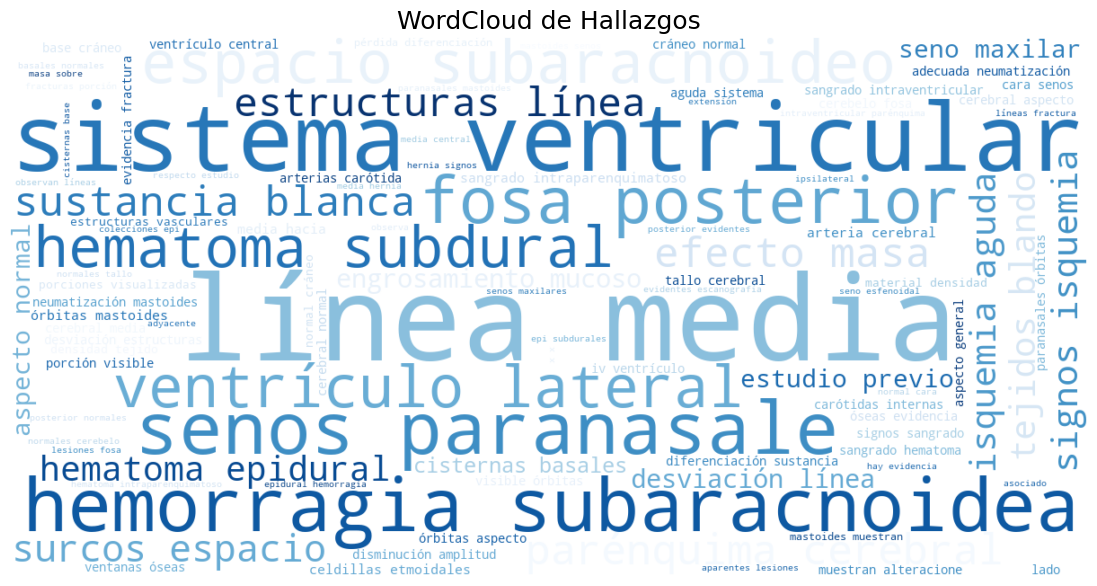

TOP 5 PALABRAS MÁS FRECUENTES EN OPINIONES (sin conectores)
cerebral             423
hematoma             418
hemorragia           334
subaracnoidea        269
media                265

TOP 20 N-GRAMAS MÁS FRECUENTES EN OPINIONES (sin conectores)
hemorragia subaracnoidea            268
arteria cerebral                    170
hematoma subdural                   163
cerebral media                      142
arteria cerebral media              138
sistema ventricular                 137
hernia subfalcina                   133
edema cerebral                      125
hematoma intraparenquimatoso        121
efecto masa                         120
línea media                         110
territorio arteria                  98
territorio arteria cerebral         95
estudio previo                      85
transformación hemorrágica          83
cerebral difuso                     82
evento isquémico                    82
edema cerebral difuso               81
hematoma epidural                   76
d

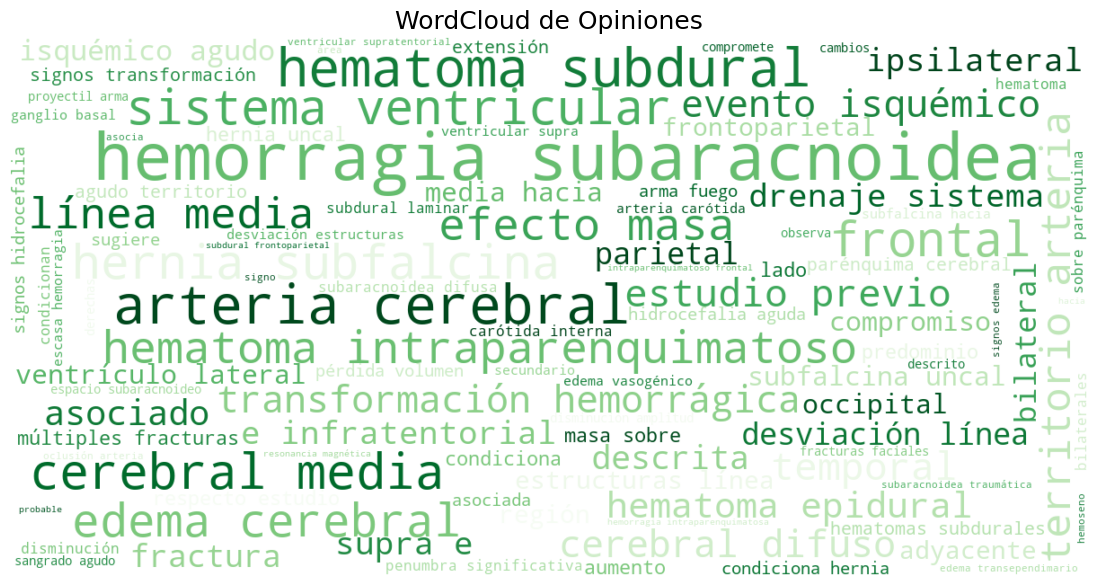

In [16]:
stopwords_es = [
    'de','la','y','el','en','del','con','se','las','los','por','para','al','lo','un','una','es','su','sus','que','a','o','sin','no','izquierdo','izquierda','derecha','derecho','mm'
]

# HALLAZGOS
all_text_h = ' '.join(df['Hallazgos'].dropna().astype(str).tolist()).lower()
words_h = re.findall(r'\b\w+\b', all_text_h)
words_h_filtradas = [w for w in words_h if w not in stopwords_es]
counter_h = Counter(words_h_filtradas)
print("TOP 5 PALABRAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)")
for palabra, freq in counter_h.most_common(5):
    print(f"{palabra:<20} {freq}")

vectorizer_h = CountVectorizer(ngram_range=(2,3), max_features=20, stop_words=stopwords_es)
X_h = vectorizer_h.fit_transform(df['Hallazgos'].dropna().astype(str).str.lower())
ngrams_h = vectorizer_h.get_feature_names_out()
counts_h = X_h.sum(axis=0).A1
ngram_freq_h = sorted(zip(ngrams_h, counts_h), key=lambda x: -x[1])
print("\nTOP 20 N-GRAMAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)")
for ngrama, freq in ngram_freq_h:
    print(f"{ngrama:<35} {freq}")

corpus_hallazgos = ' '.join(words_h_filtradas)
wc_hallazgos = WordCloud(
    width=1200, height=600, background_color='white',
    stopwords=stopwords_es, colormap='Blues', max_words=100
).generate(corpus_hallazgos)
plt.figure(figsize=(14, 7))
plt.imshow(wc_hallazgos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud de Hallazgos', fontsize=18)
plt.show()

# OPINIONES
all_text_o = ' '.join(df['Opinión'].dropna().astype(str).tolist()).lower()
words_o = re.findall(r'\b\w+\b', all_text_o)
words_o_filtradas = [w for w in words_o if w not in stopwords_es]
counter_o = Counter(words_o_filtradas)
print("TOP 5 PALABRAS MÁS FRECUENTES EN OPINIONES (sin conectores)")
for palabra, freq in counter_o.most_common(5):
    print(f"{palabra:<20} {freq}")

vectorizer_o = CountVectorizer(ngram_range=(2,3), max_features=20, stop_words=stopwords_es)
X_o = vectorizer_o.fit_transform(df['Opinión'].dropna().astype(str).str.lower())
ngrams_o = vectorizer_o.get_feature_names_out()
counts_o = X_o.sum(axis=0).A1
ngram_freq_o = sorted(zip(ngrams_o, counts_o), key=lambda x: -x[1])
print("\nTOP 20 N-GRAMAS MÁS FRECUENTES EN OPINIONES (sin conectores)")
for ngrama, freq in ngram_freq_o:
    print(f"{ngrama:<35} {freq}")

corpus_opiniones = ' '.join(words_o_filtradas)
wc_opiniones = WordCloud(
    width=1200, height=600, background_color='white',
    stopwords=stopwords_es, colormap='Greens', max_words=100
).generate(corpus_opiniones)
plt.figure(figsize=(14, 7))
plt.imshow(wc_opiniones, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud de Opiniones', fontsize=18)
plt.show()

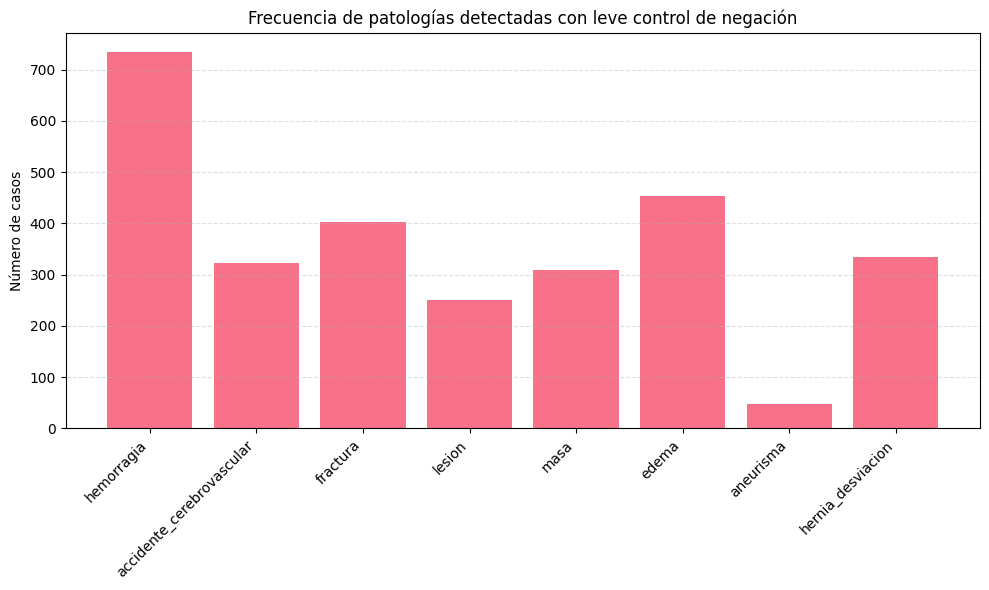

{'hemorragia': 735, 'accidente_cerebrovascular': 322, 'fractura': 402, 'lesion': 250, 'masa': 310, 'edema': 453, 'aneurisma': 48, 'hernia_desviacion': 335}


In [17]:
# 1. Diccionario clínico: patologías / sinónimos
PATOLOGIAS = {
    "hemorragia": [
        r"hemorragia", r"hematoma", r"sangrado",
        r"coleccion hematic", r"hematocele"
    ],
    "accidente_cerebrovascular": [
        r"infarto", r"isquemia", r"ictus", r"acv",
        r"evento cerebrovascular", r"hipodensidad sugestiva de isquemia"
    ],
    "fractura": [
        r"fractura", r"linea de fractura", r"trazo de fractura"
    ],
    "lesion": [
        r"lesion", r"lesiones", r"area lesion", r"contusion"
    ],
    "masa": [
        r"masa", r"lesion ocupante de espacio", r"loe", r"tumor",
        r"neoplasia", r"lesion nodular"
    ],
    "edema": [
        r"edema", r"hipodensidad difusa compatible con edema"
    ],
    "aneurisma": [
        r"aneurisma", r"dilatacion aneurismatica"
    ],
    "hernia_desviacion": [
        r"hernia", r"herniacion",
        r"desviaci[oó]n de la l[ií]nea media", r"desviacion de la linea media"
    ]
}
# 2. Negaciones robustas
NEGACIONES = [
    r"no se observa", r"no se evidencia", r"no hay",
    r"sin evidencia de", r"sin signos de", r"ausencia de",
    r"negativa para", r"niega", r"descarta"
]

# 3. Función para detección
def detectar_patologia(texto, patrones_pos, patrones_neg, ventana=60):
    if not isinstance(texto, str):
        return False

    texto = texto.lower()

    # Buscar patrones positivos
    for pos in patrones_pos:
        for match in re.finditer(pos, texto):
            start = match.start()

            # Revisar si hay negaciones antes dentro de una ventana contextual
            ventana_inicio = max(0, start - ventana)
            contexto = texto[ventana_inicio:start]

            if not any(re.search(neg, contexto) for neg in patrones_neg):
                return True

    return False

# 4. Aplicación y conteo
resultados = {}

for nombre, patrones in PATOLOGIAS.items():
    count = df["Hallazgos"].apply(
        lambda x: detectar_patologia(x, patrones, NEGACIONES)
    ).sum()

    resultados[nombre] = count

# 5. Visualización 
plt.figure(figsize=(10, 6))
plt.bar(resultados.keys(), resultados.values())
plt.ylabel("Número de casos")
plt.title("Frecuencia de patologías detectadas con leve control de negación")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print(resultados)

## Selección de categorías diagnósticas predominantes

Tras el análisis exploratorio de frecuencias y relevancia clínica, **consideramos como opción predominante** las siguientes categorías para el modelo de clasificación automática:

- hemorragia /  hematoma cerebral
- accidente cerebrovascular
- fractura
- masa

Esto por su frecuencia, relevancia clínica y claridad en los reportes. Se crearán variables binarias para cada una, que servirán como etiquetas principales en el entrenamiento y validación del modelo.

In [18]:
def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """
    Detecta patologías con análisis de contexto robusto.
    
    Args:
        texto: Texto completo del hallazgo
        keywords_positivos: Lista de palabras clave ordenada por especificidad
        keywords_negativos: Lista de términos de antigüedad/cronicidad
    
    Returns:
        1 si detecta patología aguda y presente, 0 en caso contrario
    """
    if not isinstance(texto, str):
        return 0
    
    texto = texto.lower()
    
    keywords_negativos = keywords_negativos or [
        'antiguo', 'antigua', 'antiguos', 'antiguas',
        'cronico', 'cronica', 'cronicos', 'cronicas',
        'crónico', 'crónica', 'crónicos', 'crónicas',
        'viejo', 'vieja', 'viejos', 'viejas',
        'residual', 'residuales',
        'secuela', 'secuelar', 'secuelas',
        'previo', 'previa', 'previos', 'previas',
        'conocido', 'conocida', 'conocidos', 'conocidas',
        'ya descrito', 'ya descritos', 'ya descrita', 'ya descritas',
        'ya visualizado', 'ya visualizada', 'ya visualizados', 'ya visualizadas',
        'sin cambios', 'estable', 'estables',
        'resolucion', 'resolución'
    ]
    
    negaciones_contextuales = [
        'sin', 'descarta', 'descartado', 'descartada', 'descartados', 'descartadas',
        'negativo', 'negativa', 'negativos', 'negativas',
        'ausencia', 'ausencia de', 'ausente', 'ausentes',
        'sin evidencia', 'sin evidencia de',
        'sin signos', 'sin signos de',
        'sin signos indirectos', 'sin signos indirectos de',
        'no se observa', 'no se observan',
        'no se evidencia', 'no se evidencian',
        'no se identifica', 'no se identifican',
        'libre de', 'negativo para', 'negativa para'
    ]
    
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    
    for oracion in oraciones:
        oracion = oracion.strip()
        
        keyword_encontrada = None
        for kw in keywords_ordenadas:
            if kw in oracion:
                keyword_encontrada = kw
                break
        
        if not keyword_encontrada:
            continue
        
        patron_keyword_no = re.escape(keyword_encontrada) + r'\s*:\s*no\b'
        if re.search(patron_keyword_no, oracion):
            continue
        
        patron_estructurado = re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b'
        if re.search(patron_estructurado, oracion):
            continue
        
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        
        patron_sin_hallazgos = r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada)
        if re.search(patron_sin_hallazgos, oracion):
            continue
        
        if any(ant in oracion for ant in keywords_negativos):
            continue
        
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion and keyword_encontrada in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        
        return 1
    
    return 0


# Usa df ya en memoria (normalizado en celdas anteriores)
# Mantener solo columnas originales + las 4 nuevas
columnas_originales = ['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 
                       'Datos Clínicos', 'Hallazgos', 'Opinión', 
                       'Reporte estructurado', 'Estudio Complementario Sugerido', 
                       'Hallazgo Crítico', 'Estudio Normal']

# Definir keywords
keywords_hemorragia = [
    'hemorragia subaracnoidea', 'hemorragia subaracnoideas',
    'hematoma subdural', 'hematoma epidural',
    'sangrado intraparenquimatoso', 'sangrado intraventricular',
    'hemorragia intraparenquimatosa', 'hemorragia intraventricular',
    'hemorragia interhemisferica', 'hemorragia parenquimatosa',
    'foco hemorragico', 'focos hemorragicos',
    'foco de hemorragia', 'focos de hemorragia',
    'hemorragia', 'hemorragico', 'hemorragica', 'hemorragicos', 'hemorragicas',
    'hematoma', 'hematomas',
    'sangrado', 'sangrados'
]

keywords_acv_isquemico = [
    'infarto cerebral', 'infarto lacunar', 'infartos lacunares',
    'evento isquemico', 'evento cerebrovascular',
    'area de isquemia', 'areas de isquemia',
    'zona de isquemia', 'zonas de isquemia',
    'evento vascular cerebral',
    'territorio vascular',
    'hipodensidad cortical', 'hipodensidad subcortical',
    'infarto', 'infartos',
    'isquemia', 'isquemias',
    'isquemico', 'isquemica', 'isquemicos', 'isquemicas',
    'ictus',
    'acv'
]

keywords_fractura = [
    'fractura craneal', 'fractura de craneo',
    'fractura lineal', 'fractura deprimida',
    'fractura conminuta', 'fractura hundimiento',
    'fractura', 'fracturas'
]

keywords_masa = [
    'lesion ocupante', 'lesiones ocupantes',
    'efecto de masa',
    'lesion tumoral', 'proceso expansivo',
    'proceso ocupante',
    'masa', 'masas',
    'tumor', 'tumores', 'tumoral', 'tumorales',
    'neoplasia', 'neoplasias', 'neoplasica', 'neoplasico'
]

# Aplicar detección solo a las 4 categorías
df['hemorragia'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_hemorragia)
)

df['acv'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_acv_isquemico)
)

df['fractura'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_fractura)
)

df['masa'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_masa)
)

# Mantener solo columnas necesarias
columnas_finales = columnas_originales + ['hemorragia', 'acv', 'fractura', 'masa']
df_final = df[columnas_finales]

df_final.to_excel('../../data_cleaned.xlsx', index=False)

print(f"Hemorragia: {df_final['hemorragia'].sum()} casos")
print(f"ACV isquémico: {df_final['acv'].sum()} casos")
print(f"Fractura: {df_final['fractura'].sum()} casos")
print(f"Masa: {df_final['masa'].sum()} casos")
print(f"\nArchivo guardado: {df_final.shape[0]} filas, {df_final.shape[1]} columnas")

for col in ['hemorragia', 'acv', 'fractura', 'masa']:
    print(f"\nEjemplos donde {col}=1:")
    display(df_final[df_final[col]==1][['Hallazgos', col, 'Hallazgo Crítico']].sample(5, random_state=1))

Hemorragia: 719 casos
ACV isquémico: 397 casos
Fractura: 380 casos
Masa: 210 casos

Archivo guardado: 895 filas, 15 columnas

Ejemplos donde hemorragia=1:


,Hallazgos,hemorragia,Hallazgo Crítico
658,signos de sangrado. hematoma subdural: no. hem...,1,1
667,"signos de sangrado. hematoma subdural: sí, fro...",1,1
2589,hemorragia intraparenquimatosa: hemorragia fro...,1,1
3873,hematoma intraparenquimatoso agudo en la regió...,1,1
80,signos de sangrado. hematoma subdural: hemisfé...,1,1



Ejemplos donde acv=1:


,Hallazgos,acv,Hallazgo Crítico
3385,signos de sangrado. hematoma subdural: no. hem...,1,1
3899,"signos de sangrado. hematoma subdural: si, int...",1,1
3593,"signos de sangrado. hematoma subdural: si, fro...",1,1
3648,hipodensidades que compromete la sustancia bla...,1,1
3669,"signos de sangrado. hematoma subdural: si, tem...",1,1



Ejemplos donde fractura=1:


,Hallazgos,fractura,Hallazgo Crítico
3579,signos de sangrado. hematoma subdural: no. hem...,1,1
3303,signos de sangrado. hematoma subdural: parieta...,1,1
3671,"laceración transfixiante intraparenquimatosa, ...",1,1
3381,signos de sangrado. hematoma subdural: hematom...,1,1
3530,herida por proyectil de arma de fuego que cond...,1,1



Ejemplos donde masa=1:


,Hallazgos,masa,Hallazgo Crítico
2469,"hematoma subdural heterogéneo, hemisférico izq...",1,1
3883,hematoma parenquimatoso frontoparietal derecho...,1,1
2927,signos de sangrado. hematoma subdural: no. hem...,1,1
3974,hematoma subdural holohemisférico derecho dens...,1,1
1948,cambios de craneotomía frontoparietal izquierd...,1,1


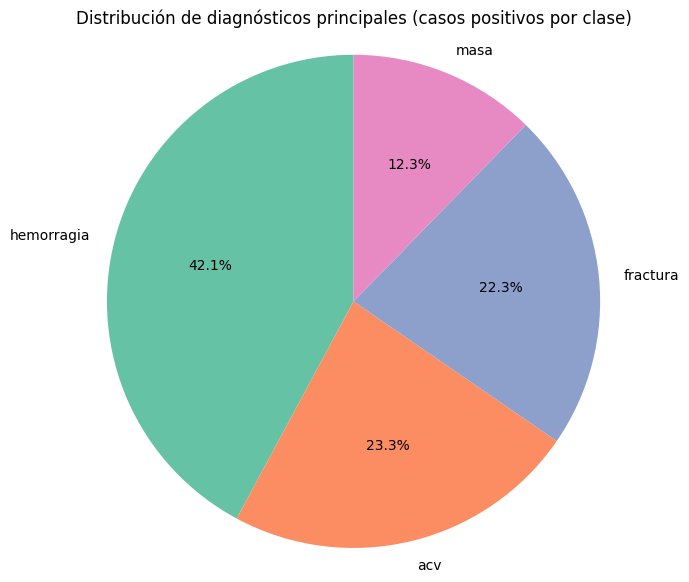

In [19]:
# Leer el archivo con las 4 columnas binarias
df = pd.read_excel('../../data_cleaned.xlsx')

# Contar positivos por clase
labels = ['hemorragia', 'acv', 'fractura', 'masa']
counts = [df[col].sum() for col in labels]

# Gráfica de torta
plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Distribución de diagnósticos principales (casos positivos por clase)')
plt.axis('equal')
plt.show()